# FraudGuard — 05: XGBoost

`scale_pos_weight=577` (neg/pos oranı) ile eğitilen ana model. LR ve RF ile karşılaştırma yapılır.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
import json
import joblib
from pathlib import Path
from xgboost import XGBClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve,
    precision_score, recall_score, f1_score
)

np.random.seed(42)

PROCESSED_DIR = Path('../data/processed')
MODELS_DIR    = Path('../models')
METRICS_DIR   = Path('../results/metrics')
FIGURES_DIR   = Path('../results/figures')

In [2]:
with open('../config/model_params.yaml', 'r') as f:
    cfg = yaml.safe_load(f)

XGB_CFG = cfg['xgboost']
print('XGBoost config:', XGB_CFG)

XGBoost config: {'random_state': 42, 'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': 577}


## 1. Veriyi Yükle

In [3]:
X_train = pd.read_csv(PROCESSED_DIR / 'X_train_scaled.csv')
X_test  = pd.read_csv(PROCESSED_DIR / 'X_test_scaled.csv')
y_train = pd.read_csv(PROCESSED_DIR / 'y_train.csv').squeeze()
y_test  = pd.read_csv(PROCESSED_DIR / 'y_test.csv').squeeze()

n_neg = int((y_train == 0).sum())
n_pos = int((y_train == 1).sum())
print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'Train — Normal: {n_neg:,}  |  Fraud: {n_pos:,}')
print(f'scale_pos_weight (config): {XGB_CFG["scale_pos_weight"]}  |  gerçek oran: {n_neg/n_pos:.1f}')
print(f'Test  fraud: {y_test.sum()}  ({y_test.mean():.4%})')

X_train: (227845, 30)  |  X_test: (56962, 30)
Train — Normal: 227,451  |  Fraud: 394
scale_pos_weight (config): 577  |  gerçek oran: 577.3
Test  fraud: 98  (0.1720%)


## 2. Model Eğitimi

In [4]:
model = XGBClassifier(**XGB_CFG, eval_metric='logloss', verbosity=0)

model.fit(X_train, y_train)
print('Model eğitildi.')
print(f'Ağaç sayısı       : {model.n_estimators}')
print(f'scale_pos_weight  : {model.scale_pos_weight}')
print(f'Özellik sayısı    : {model.n_features_in_}')

Model eğitildi.
Ağaç sayısı       : 100
scale_pos_weight  : 577
Özellik sayısı    : 30


## 3. Tahmin

In [5]:
y_pred       = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print('Tahmin tamamlandı.')
print(f'Tahmin edilen fraud sayısı: {y_pred.sum()}')
print(f'Gerçek fraud sayısı:        {y_test.sum()}')

Tahmin tamamlandı.
Tahmin edilen fraud sayısı: 107
Gerçek fraud sayısı:        98


## 4. Metrikler

In [6]:
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_pred_proba)
pr_auc    = average_precision_score(y_test, y_pred_proba)

print('=== XGBoost — Test Seti Metrikleri ===')
print(f'Precision : {precision:.4f}')
print(f'Recall    : {recall:.4f}')
print(f'F1        : {f1:.4f}')
print(f'ROC-AUC   : {roc_auc:.4f}')
print(f'PR-AUC    : {pr_auc:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraud']))

=== XGBoost — Test Seti Metrikleri ===
Precision : 0.7757
Recall    : 0.8469
F1        : 0.8098
ROC-AUC   : 0.9815
PR-AUC    : 0.8597

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.78      0.85      0.81        98

    accuracy                           1.00     56962
   macro avg       0.89      0.92      0.90     56962
weighted avg       1.00      1.00      1.00     56962



In [7]:
with open(METRICS_DIR / '05_baseline_metrics.json', 'r') as f:
    lr_metrics = json.load(f)
with open(METRICS_DIR / '06_random_forest_metrics.json', 'r') as f:
    rf_metrics = json.load(f)

comparison = pd.DataFrame([
    {
        'Model'    : 'Logistic Regression (baseline)',
        'Precision': lr_metrics['precision'],
        'Recall'   : lr_metrics['recall'],
        'F1'       : lr_metrics['f1'],
        'ROC-AUC'  : lr_metrics['roc_auc'],
        'PR-AUC'   : lr_metrics['pr_auc'],
    },
    {
        'Model'    : 'Random Forest (balanced)',
        'Precision': rf_metrics['precision'],
        'Recall'   : rf_metrics['recall'],
        'F1'       : rf_metrics['f1'],
        'ROC-AUC'  : rf_metrics['roc_auc'],
        'PR-AUC'   : rf_metrics['pr_auc'],
    },
    {
        'Model'    : 'XGBoost (scale_pos_weight=577)',
        'Precision': round(float(precision), 4),
        'Recall'   : round(float(recall),    4),
        'F1'       : round(float(f1),        4),
        'ROC-AUC'  : round(float(roc_auc),   4),
        'PR-AUC'   : round(float(pr_auc),    4),
    },
]).set_index('Model')

print('=== 3 Model Karşılaştırması ===')
print(comparison.to_string())

=== 3 Model Karşılaştırması ===
                                Precision  Recall      F1  ROC-AUC  PR-AUC
Model                                                                     
Logistic Regression (baseline)     0.8267  0.6327  0.7168   0.9605  0.7414
Random Forest (balanced)           0.9605  0.7449  0.8391   0.9529  0.8539
XGBoost (scale_pos_weight=577)     0.7757  0.8469  0.8098   0.9815  0.8597


## 5. Confusion Matrix

TN=56,840  FP=24  FN=15  TP=83


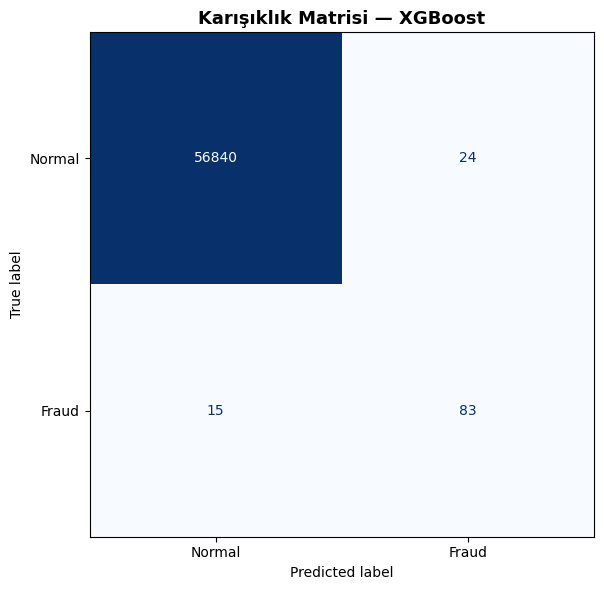

Saved: 12_xgb_confusion_matrix.png


In [8]:
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Fraud'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Karışıklık Matrisi — XGBoost', fontsize=13, fontweight='bold')

tn, fp, fn, tp = cm.ravel()
print(f'TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '12_xgb_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 12_xgb_confusion_matrix.png')

## 6. ROC ve PR Eğrileri

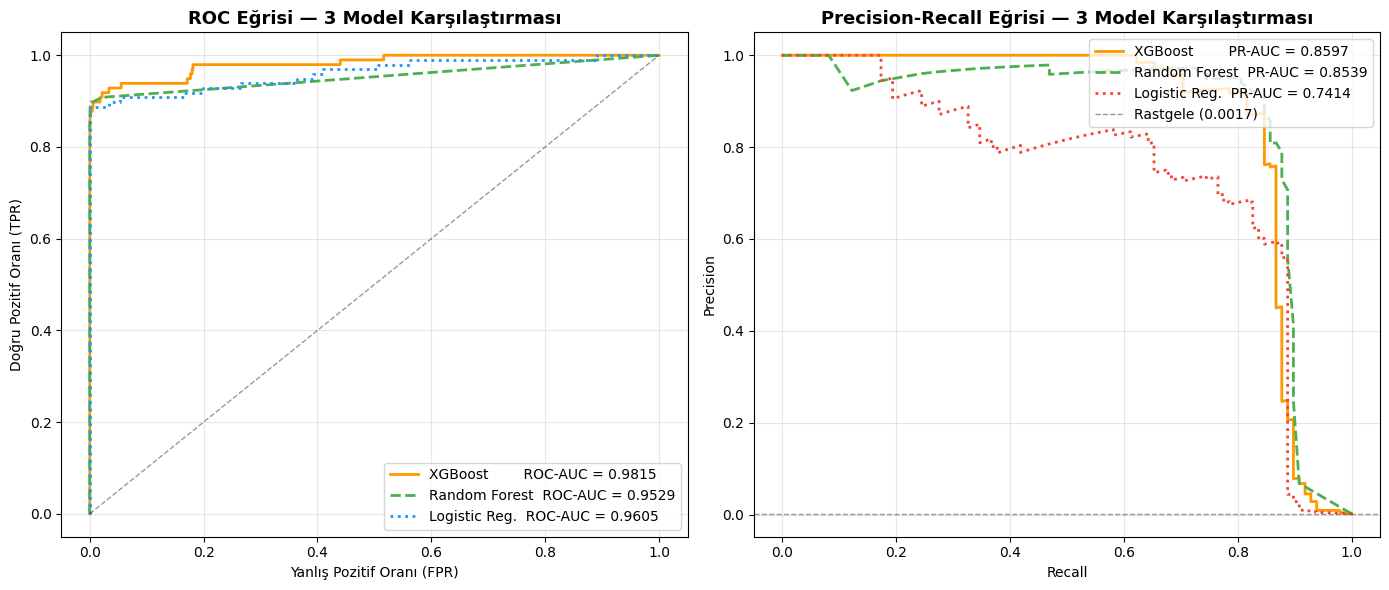

Saved: 13_xgb_roc_pr_curves.png


In [9]:
lr_model      = joblib.load(MODELS_DIR / 'logistic_regression.pkl')
rf_model      = joblib.load(MODELS_DIR / 'random_forest.pkl')
lr_proba      = lr_model.predict_proba(X_test)[:, 1]
rf_proba      = rf_model.predict_proba(X_test)[:, 1]

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba)
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, rf_proba)
fpr_lr,  tpr_lr,  _ = roc_curve(y_test, lr_proba)

prec_xgb, rec_xgb, _ = precision_recall_curve(y_test, y_pred_proba)
prec_rf,  rec_rf,  _ = precision_recall_curve(y_test, rf_proba)
prec_lr,  rec_lr,  _ = precision_recall_curve(y_test, lr_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC
axes[0].plot(fpr_xgb, tpr_xgb, color='#FF9800', lw=2,
             label=f'XGBoost        ROC-AUC = {roc_auc:.4f}')
axes[0].plot(fpr_rf,  tpr_rf,  color='#4CAF50', lw=2, linestyle='--',
             label=f'Random Forest  ROC-AUC = {rf_metrics["roc_auc"]:.4f}')
axes[0].plot(fpr_lr,  tpr_lr,  color='#2196F3', lw=2, linestyle=':',
             label=f'Logistic Reg.  ROC-AUC = {lr_metrics["roc_auc"]:.4f}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4)
axes[0].set_xlabel('Yanlış Pozitif Oranı (FPR)')
axes[0].set_ylabel('Doğru Pozitif Oranı (TPR)')
axes[0].set_title('ROC Eğrisi — 3 Model Karşılaştırması', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# PR
baseline_rate = y_test.mean()
axes[1].plot(rec_xgb, prec_xgb, color='#FF9800', lw=2,
             label=f'XGBoost        PR-AUC = {pr_auc:.4f}')
axes[1].plot(rec_rf,  prec_rf,  color='#4CAF50', lw=2, linestyle='--',
             label=f'Random Forest  PR-AUC = {rf_metrics["pr_auc"]:.4f}')
axes[1].plot(rec_lr,  prec_lr,  color='#F44336', lw=2, linestyle=':',
             label=f'Logistic Reg.  PR-AUC = {lr_metrics["pr_auc"]:.4f}')
axes[1].axhline(y=baseline_rate, color='k', linestyle='--', lw=1, alpha=0.4,
                label=f'Rastgele ({baseline_rate:.4f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Eğrisi — 3 Model Karşılaştırması', fontsize=13, fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '13_xgb_roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 13_xgb_roc_pr_curves.png')

## 7. Feature Importance

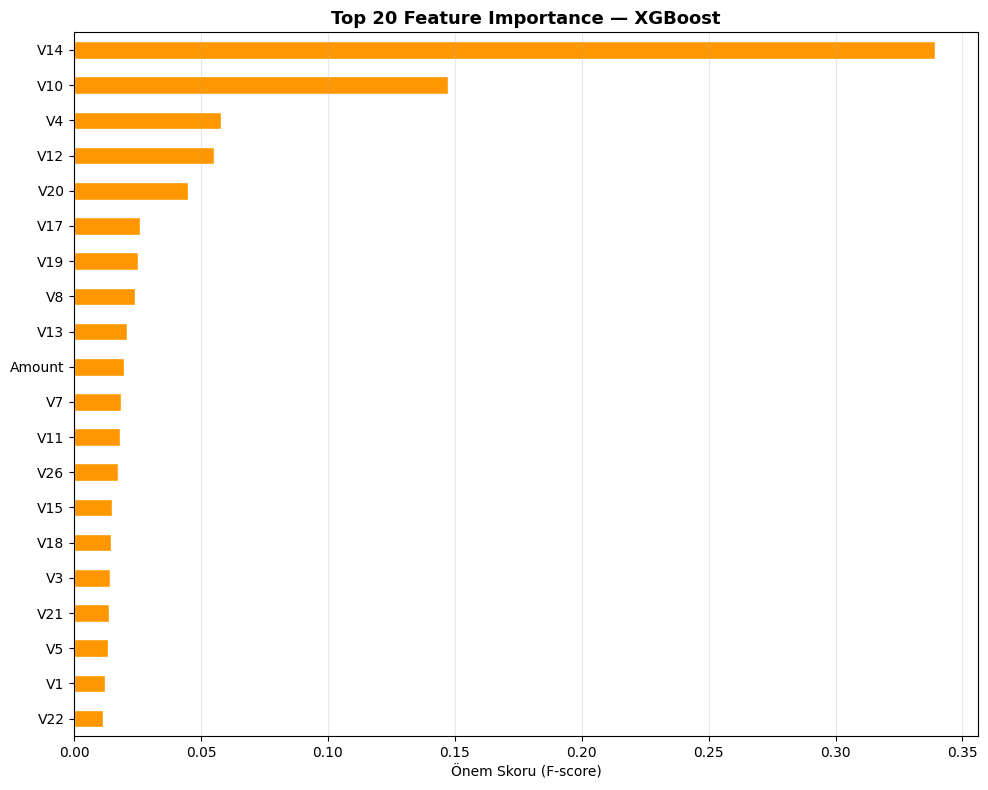

Saved: 14_xgb_feature_importance.png

Top 5 feature:
V14    0.339261
V10    0.147391
V4     0.057702
V12    0.055237
V20    0.044800


In [10]:
importances = pd.Series(model.feature_importances_, index=X_train.columns)
top20 = importances.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
top20.plot(kind='barh', ax=ax, color='#FF9800', edgecolor='white')
ax.set_xlabel('Önem Skoru (F-score)')
ax.set_title('Top 20 Feature Importance — XGBoost', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '14_xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 14_xgb_feature_importance.png')
print()
print('Top 5 feature:')
print(importances.nlargest(5).to_string())

## 8. Model ve Metrik Kaydet

In [11]:
joblib.dump(model, MODELS_DIR / 'xgboost.pkl')
print('Model kaydedildi: models/xgboost.pkl')

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

metrics = {
    'model'           : 'XGBClassifier',
    'step'            : '07_xgboost',
    'scale_pos_weight': XGB_CFG['scale_pos_weight'],
    'smote'           : False,
    'n_estimators'    : XGB_CFG['n_estimators'],
    'max_depth'       : XGB_CFG['max_depth'],
    'learning_rate'   : XGB_CFG['learning_rate'],
    'precision'       : round(float(precision), 4),
    'recall'          : round(float(recall),    4),
    'f1'              : round(float(f1),        4),
    'roc_auc'         : round(float(roc_auc),   4),
    'pr_auc'          : round(float(pr_auc),    4),
    'confusion_matrix': {
        'TN': int(tn), 'FP': int(fp),
        'FN': int(fn), 'TP': int(tp)
    }
}

with open(METRICS_DIR / '07_xgboost_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print(json.dumps(metrics, indent=2))
print('\nSaved: 07_xgboost_metrics.json')

Model kaydedildi: models/xgboost.pkl
{
  "model": "XGBClassifier",
  "step": "07_xgboost",
  "scale_pos_weight": 577,
  "smote": false,
  "n_estimators": 100,
  "max_depth": 6,
  "learning_rate": 0.1,
  "precision": 0.7757,
  "recall": 0.8469,
  "f1": 0.8098,
  "roc_auc": 0.9815,
  "pr_auc": 0.8597,
  "confusion_matrix": {
    "TN": 56840,
    "FP": 24,
    "FN": 15,
    "TP": 83
  }
}

Saved: 07_xgboost_metrics.json
